# Knowledge Distillation on CIFAR-10

This notebook studies **knowledge distillation** for image classification on **CIFAR-10**. A larger **teacher** model is used to guide a smaller **student** model. The goal is to test whether the distilled student can achieve better performance than a baseline student trained with standard supervision, while keeping the same small architecture.

## What this notebook includes
- CIFAR-10 data loading and preprocessing
- A **teacher** model (ResNet-18)
- A **student** model (small CNN)
- Baseline student training with cross-entropy
- Distilled student training with teacher soft targets
- Evaluation: accuracy, parameter count, inference time
- Hyperparameter sweep for temperature and alpha
- Saved checkpoints, metrics, and plots
- A small demo with sample predictions


In [1]:
# Imports and setup
import json
import time
import copy
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from torchvision.models import ResNet18_Weights

plt.rcParams['figure.figsize'] = (8, 5)


In [ ]:
# Configuration
SEED = 42
DATA_ROOT = './data'
CHECKPOINT_DIR = Path('./checkpoints')
RESULTS_DIR = Path('./results')
PLOTS_DIR = RESULTS_DIR / 'plots'

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', DEVICE)

# Training toggles. For grading/demo runs, keep these False to load saved checkpoints/results.
TRAIN_TEACHER = False
TRAIN_BASELINE = False
TRAIN_DISTILLED = False
RUN_SWEEP = True

# Data settings
BATCH_SIZE = 128
NUM_WORKERS = 1
PIN_MEMORY = DEVICE.type == 'cuda'
VAL_RATIO = 0.1

# Teacher optimization settings
TEACHER_EPOCHS = 30
TEACHER_LR = 0.03
TEACHER_WEIGHT_DECAY = 5e-4

# Student optimization settings
STUDENT_EPOCHS = 30
STUDENT_LR = 3e-3
STUDENT_WEIGHT_DECAY = 1e-4

# Final distillation hyperparameters selected from the sweep
TEMPERATURE = 8.0
ALPHA = 0.5
SWEEP_EPOCHS = 5

# Paths
TEACHER_PATH = CHECKPOINT_DIR / 'teacher_resnet18.pth'
BASELINE_PATH = CHECKPOINT_DIR / 'student_baseline.pth'
DISTILLED_PATH = CHECKPOINT_DIR / 'student_distilled.pth'
METRICS_PATH = RESULTS_DIR / 'metrics.json'
EXPERIMENTS_PATH = RESULTS_DIR / 'experiment_results.csv'


Using device: cuda


In [3]:
# Reproducibility

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)


## Data Preparation

CIFAR-10 contains 10 classes of small natural images. We use data augmentation during training and standard normalization for all splits. A validation split is created from the training set.


In [4]:
# CIFAR-10 transforms and dataloaders
MEAN = (0.4914, 0.4822, 0.4465)
STD = (0.2470, 0.2435, 0.2616)


def denormalize(x, mean=MEAN, std=STD):
    """Undo CIFAR-10 normalization so an image tensor can be displayed."""
    x = x.detach().cpu()
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    return x * std + mean


def make_loader(dataset, batch_size=BATCH_SIZE, shuffle=False):
    """Create a DataLoader with GPU-friendly defaults."""
    kwargs = {
        'batch_size': batch_size,
        'shuffle': shuffle,
        'num_workers': NUM_WORKERS,
        'pin_memory': PIN_MEMORY,
    }
    if NUM_WORKERS > 0:
        kwargs['persistent_workers'] = True
    return DataLoader(dataset, **kwargs)


teacher_train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.AutoAugment(transforms.AutoAugmentPolicy.CIFAR10),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
    transforms.RandomErasing(p=0.25),
])

student_train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

teacher_full_train = datasets.CIFAR10(root=DATA_ROOT, train=True, download=True, transform=teacher_train_transform)
student_full_train = datasets.CIFAR10(root=DATA_ROOT, train=True, download=True, transform=student_train_transform)
full_train_for_eval = datasets.CIFAR10(root=DATA_ROOT, train=True, download=True, transform=eval_transform)
test_dataset = datasets.CIFAR10(root=DATA_ROOT, train=False, download=True, transform=eval_transform)

val_size = int(len(student_full_train) * VAL_RATIO)
train_size = len(student_full_train) - val_size

split_generator = torch.Generator().manual_seed(SEED)
teacher_train_dataset, _ = random_split(teacher_full_train, [train_size, val_size], generator=split_generator)

split_generator = torch.Generator().manual_seed(SEED)
student_train_dataset, _ = random_split(student_full_train, [train_size, val_size], generator=split_generator)

split_generator = torch.Generator().manual_seed(SEED)
_, val_dataset = random_split(full_train_for_eval, [train_size, val_size], generator=split_generator)

teacher_train_loader = make_loader(teacher_train_dataset, shuffle=True)
student_train_loader = make_loader(student_train_dataset, shuffle=True)
val_loader = make_loader(val_dataset, shuffle=False)
test_loader = make_loader(test_dataset, shuffle=False)

classes = test_dataset.classes
print('Train size:', len(student_train_dataset))
print('Val size:', len(val_dataset))
print('Test size:', len(test_dataset))
print('Classes:', classes)


Train size: 45000
Val size: 5000
Test size: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## Model Definitions

The teacher is a larger **ResNet-18** model. The student is a much smaller CNN. The baseline and distilled students use the **same architecture** so any performance difference can be attributed to the training method rather than model size.


In [5]:
# Model definitions
class SmallCNN(nn.Module):
    def __init__(self, num_classes=10, base_channels=32):
        super().__init__()
        c = base_channels
        self.features = nn.Sequential(
            nn.Conv2d(3, c, kernel_size=3, padding=1),
            nn.BatchNorm2d(c),
            nn.ReLU(inplace=True),
            nn.Conv2d(c, c, kernel_size=3, padding=1),
            nn.BatchNorm2d(c),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(c, 2 * c, kernel_size=3, padding=1),
            nn.BatchNorm2d(2 * c),
            nn.ReLU(inplace=True),
            nn.Conv2d(2 * c, 2 * c, kernel_size=3, padding=1),
            nn.BatchNorm2d(2 * c),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(2 * c, 4 * c, kernel_size=3, padding=1),
            nn.BatchNorm2d(4 * c),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Linear(4 * c, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)


def get_teacher_model(num_classes=10, use_pretrained=True):
    """Create a CIFAR-friendly ResNet-18 teacher."""
    if use_pretrained:
        try:
            teacher = models.resnet18(weights=ResNet18_Weights.DEFAULT)
            print('Loaded pretrained ResNet-18 weights.')
        except Exception as e:
            print('Could not load pretrained weights. Falling back to randomly initialized ResNet-18.')
            print('Reason:', e)
            teacher = models.resnet18(weights=None)
    else:
        teacher = models.resnet18(weights=None)
        print('Created ResNet-18 architecture without downloading pretrained weights.')

    # CIFAR-10 images are 32x32. The default ImageNet stem downsamples too aggressively.
    teacher.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    teacher.maxpool = nn.Identity()
    teacher.fc = nn.Linear(teacher.fc.in_features, num_classes)
    return teacher


def get_student_model(base_channels=32, num_classes=10):
    return SmallCNN(num_classes=num_classes, base_channels=base_channels)


In [6]:
# Utility helpers

def count_parameters(model, trainable_only=False):
    """Count model parameters. By default, count all parameters, even if frozen."""
    if trainable_only:
        return sum(p.numel() for p in model.parameters() if p.requires_grad)
    return sum(p.numel() for p in model.parameters())


def save_checkpoint(path, model, extra=None):
    payload = {'model_state_dict': model.state_dict()}
    if extra is not None:
        payload.update(extra)
    torch.save(payload, path)


def load_checkpoint(path, model, map_location=DEVICE):
    payload = torch.load(path, map_location=map_location)
    state_dict = payload['model_state_dict'] if 'model_state_dict' in payload else payload
    model.load_state_dict(state_dict)
    return payload


In [7]:
# Training and evaluation loops

@torch.no_grad()
def evaluate_model(model, loader, criterion=None, device=DEVICE):
    model.eval()
    running_loss = 0.0
    running_correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=PIN_MEMORY)
        labels = labels.to(device, non_blocking=PIN_MEMORY)
        logits = model(images)

        if criterion is not None:
            running_loss += criterion(logits, labels).item() * images.size(0)
        running_correct += (logits.argmax(dim=1) == labels).sum().item()
        total += images.size(0)

    avg_loss = running_loss / total if criterion is not None else None
    avg_acc = running_correct / total
    return avg_loss, avg_acc


def fit_teacher(model, train_loader, val_loader, epochs, lr=TEACHER_LR, weight_decay=TEACHER_WEIGHT_DECAY, device=DEVICE):
    """Fine-tune the ResNet-18 teacher with a CIFAR-friendly training schedule."""
    model = model.to(device)
    for p in model.parameters():
        p.requires_grad = True

    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = torch.optim.SGD(
        model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay, nesterov=True
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_state = copy.deepcopy(model.state_dict())
    best_val_acc = 0.0

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        running_correct = 0
        total = 0

        for images, labels in train_loader:
            images = images.to(device, non_blocking=PIN_MEMORY)
            labels = labels.to(device, non_blocking=PIN_MEMORY)

            optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            running_correct += (logits.argmax(dim=1) == labels).sum().item()
            total += images.size(0)

        scheduler.step()

        train_loss = running_loss / total
        train_acc = running_correct / total
        val_loss, val_acc = evaluate_model(model, val_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())

        current_lr = optimizer.param_groups[0]['lr']
        print(
            f'Epoch {epoch + 1}/{epochs} | lr={current_lr:.5f} | '
            f'train_loss={train_loss:.4f} train_acc={train_acc:.4f} | '
            f'val_loss={val_loss:.4f} val_acc={val_acc:.4f}'
        )

    model.load_state_dict(best_state)
    return model, history, best_val_acc


def fit_supervised_student(model, train_loader, val_loader, epochs, lr=STUDENT_LR,
                           weight_decay=STUDENT_WEIGHT_DECAY, device=DEVICE):
    """Train the baseline student with standard cross-entropy loss."""
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=lr, epochs=epochs, steps_per_epoch=len(train_loader)
    )

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_state = copy.deepcopy(model.state_dict())
    best_val_acc = 0.0

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        running_correct = 0
        total = 0

        for images, labels in train_loader:
            images = images.to(device, non_blocking=PIN_MEMORY)
            labels = labels.to(device, non_blocking=PIN_MEMORY)

            optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            scheduler.step()

            running_loss += loss.item() * images.size(0)
            running_correct += (logits.argmax(dim=1) == labels).sum().item()
            total += images.size(0)

        train_loss = running_loss / total
        train_acc = running_correct / total
        val_loss, val_acc = evaluate_model(model, val_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())

        current_lr = optimizer.param_groups[0]['lr']
        print(
            f'Epoch {epoch + 1}/{epochs} | lr={current_lr:.6f} | '
            f'train_loss={train_loss:.4f} train_acc={train_acc:.4f} | '
            f'val_loss={val_loss:.4f} val_acc={val_acc:.4f}'
        )

    model.load_state_dict(best_state)
    return model, history, best_val_acc


## Knowledge Distillation Loss

The distilled student minimizes a weighted combination of:
1. **Cross-entropy loss** with the ground-truth labels
2. **Distillation loss** between the student and teacher soft predictions

A **temperature** parameter controls how soft the teacher distribution is. Higher temperatures reveal more information about relationships among classes.


In [8]:
# Knowledge distillation utilities

def distillation_loss(student_logits, teacher_logits, labels, temperature=TEMPERATURE, alpha=ALPHA):
    """Combined hard-label cross-entropy and soft-label KL-divergence loss."""
    ce_loss = F.cross_entropy(student_logits, labels)

    student_log_probs = F.log_softmax(student_logits / temperature, dim=1)
    teacher_probs = F.softmax(teacher_logits / temperature, dim=1).detach()
    kd_loss = F.kl_div(student_log_probs, teacher_probs, reduction='batchmean') * (temperature ** 2)

    total_loss = alpha * kd_loss + (1 - alpha) * ce_loss
    return total_loss, ce_loss.detach(), kd_loss.detach()


def fit_distillation_student(student, teacher, train_loader, val_loader, epochs, temperature=TEMPERATURE,
                             alpha=ALPHA, lr=STUDENT_LR, weight_decay=STUDENT_WEIGHT_DECAY,
                             device=DEVICE):
    """Train the student with knowledge distillation from the frozen teacher."""
    student = student.to(device)
    teacher = teacher.to(device)
    teacher.eval()
    for p in teacher.parameters():
        p.requires_grad = False

    optimizer = torch.optim.AdamW(student.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=lr, epochs=epochs, steps_per_epoch=len(train_loader)
    )

    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': [],
        'ce_loss': [], 'kd_loss': []
    }
    best_state = copy.deepcopy(student.state_dict())
    best_val_acc = 0.0
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        student.train()
        running_loss = 0.0
        running_correct = 0
        running_ce = 0.0
        running_kd = 0.0
        total = 0

        for images, labels in train_loader:
            images = images.to(device, non_blocking=PIN_MEMORY)
            labels = labels.to(device, non_blocking=PIN_MEMORY)

            optimizer.zero_grad()
            with torch.no_grad():
                teacher_logits = teacher(images)

            student_logits = student(images)
            loss, ce, kd = distillation_loss(
                student_logits, teacher_logits, labels,
                temperature=temperature, alpha=alpha
            )
            loss.backward()
            optimizer.step()
            scheduler.step()

            running_loss += loss.item() * images.size(0)
            running_ce += ce.item() * images.size(0)
            running_kd += kd.item() * images.size(0)
            running_correct += (student_logits.argmax(dim=1) == labels).sum().item()
            total += images.size(0)

        train_loss = running_loss / total
        train_acc = running_correct / total
        train_ce = running_ce / total
        train_kd = running_kd / total
        val_loss, val_acc = evaluate_model(student, val_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['ce_loss'].append(train_ce)
        history['kd_loss'].append(train_kd)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(student.state_dict())

        current_lr = optimizer.param_groups[0]['lr']
        print(
            f'Epoch {epoch + 1}/{epochs} | lr={current_lr:.6f} | '
            f'train_loss={train_loss:.4f} train_acc={train_acc:.4f} | '
            f'ce={train_ce:.4f} kd={train_kd:.4f} | '
            f'val_loss={val_loss:.4f} val_acc={val_acc:.4f}'
        )

    student.load_state_dict(best_state)
    return student, history, best_val_acc


## Train or Load the Teacher

A pretrained ResNet-18 is used as the teacher. If `TRAIN_TEACHER=False`, the notebook will try to load a saved checkpoint instead. This makes the notebook easier to rerun during grading.


In [9]:
# Teacher model
# If a saved checkpoint exists, pretrained ImageNet weights are not needed just to create the architecture.
use_pretrained_teacher = TRAIN_TEACHER or not TEACHER_PATH.exists()
teacher = get_teacher_model(num_classes=10, use_pretrained=use_pretrained_teacher)
print('Teacher parameters:', f'{count_parameters(teacher):,}')

if TRAIN_TEACHER:
    teacher, teacher_history, teacher_best_val = fit_teacher(
        teacher,
        teacher_train_loader,
        val_loader,
        epochs=TEACHER_EPOCHS,
        lr=TEACHER_LR,
        weight_decay=TEACHER_WEIGHT_DECAY,
    )
    save_checkpoint(TEACHER_PATH, teacher, extra={'history': teacher_history, 'best_val_acc': teacher_best_val})
    print(f'Saved teacher checkpoint to {TEACHER_PATH}')
elif TEACHER_PATH.exists():
    teacher_payload = load_checkpoint(TEACHER_PATH, teacher)
    teacher_history = teacher_payload.get('history', None)
    print(f'Loaded teacher checkpoint from {TEACHER_PATH}')
else:
    teacher_history = None
    print('No saved teacher checkpoint found. Set TRAIN_TEACHER=True to create one.')

teacher = teacher.to(DEVICE)


Loaded pretrained ResNet-18 weights.
Teacher parameters: 11,173,962
Epoch 1/30 | lr=0.02992 | train_loss=1.5086 train_acc=0.5787 | val_loss=1.0837 val_acc=0.7524
Epoch 2/30 | lr=0.02967 | train_loss=1.0984 train_acc=0.7432 | val_loss=0.8838 val_acc=0.8388
Epoch 3/30 | lr=0.02927 | train_loss=1.0061 train_acc=0.7837 | val_loss=0.8252 val_acc=0.8760
Epoch 4/30 | lr=0.02870 | train_loss=0.9544 train_acc=0.8045 | val_loss=0.8352 val_acc=0.8620
Epoch 5/30 | lr=0.02799 | train_loss=0.9220 train_acc=0.8189 | val_loss=0.7469 val_acc=0.8994
Epoch 6/30 | lr=0.02714 | train_loss=0.8947 train_acc=0.8315 | val_loss=0.7550 val_acc=0.8944
Epoch 7/30 | lr=0.02615 | train_loss=0.8766 train_acc=0.8384 | val_loss=0.7338 val_acc=0.9000
Epoch 8/30 | lr=0.02504 | train_loss=0.8572 train_acc=0.8454 | val_loss=0.7693 val_acc=0.8860
Epoch 9/30 | lr=0.02382 | train_loss=0.8459 train_acc=0.8512 | val_loss=0.7207 val_acc=0.9078
Epoch 10/30 | lr=0.02250 | train_loss=0.8287 train_acc=0.8579 | val_loss=0.7222 val_ac

## Train or Load the Baseline Student


In [10]:
# Fair starting point for both student models
# The baseline and distilled students use the same initial weights, so differences come from training method.
set_seed(SEED)
initial_student = get_student_model(base_channels=32)
initial_student_state = copy.deepcopy(initial_student.state_dict())


In [11]:
# Baseline student
baseline_student = get_student_model(base_channels=32)
baseline_student.load_state_dict(initial_student_state)
print('Baseline student parameters:', f'{count_parameters(baseline_student):,}')

if TRAIN_BASELINE:
    baseline_student, baseline_history, baseline_best_val = fit_supervised_student(
        baseline_student,
        student_train_loader,
        val_loader,
        epochs=STUDENT_EPOCHS,
        lr=STUDENT_LR,
        weight_decay=STUDENT_WEIGHT_DECAY,
    )
    save_checkpoint(BASELINE_PATH, baseline_student, extra={'history': baseline_history, 'best_val_acc': baseline_best_val})
    print(f'Saved baseline checkpoint to {BASELINE_PATH}')
elif BASELINE_PATH.exists():
    baseline_payload = load_checkpoint(BASELINE_PATH, baseline_student)
    baseline_history = baseline_payload.get('history', None)
    print(f'Loaded baseline checkpoint from {BASELINE_PATH}')
else:
    baseline_history = None
    print('No saved baseline checkpoint found. Set TRAIN_BASELINE=True to create one.')

baseline_student = baseline_student.to(DEVICE)


Baseline student parameters: 141,354


Epoch 1/30 | lr=0.000207 | train_loss=1.7614 train_acc=0.3740 | val_loss=1.4658 val_acc=0.4760
Epoch 2/30 | lr=0.000457 | train_loss=1.3392 train_acc=0.5277 | val_loss=1.1856 val_acc=0.5752
Epoch 3/30 | lr=0.000840 | train_loss=1.1346 train_acc=0.5972 | val_loss=1.5953 val_acc=0.4658
Epoch 4/30 | lr=0.001311 | train_loss=1.0055 train_acc=0.6412 | val_loss=1.2741 val_acc=0.5866
Epoch 5/30 | lr=0.001811 | train_loss=0.8993 train_acc=0.6832 | val_loss=1.1128 val_acc=0.6426
Epoch 6/30 | lr=0.002281 | train_loss=0.8212 train_acc=0.7122 | val_loss=1.0054 val_acc=0.6624
Epoch 7/30 | lr=0.002664 | train_loss=0.7511 train_acc=0.7395 | val_loss=0.8793 val_acc=0.7018
Epoch 8/30 | lr=0.002914 | train_loss=0.6941 train_acc=0.7586 | val_loss=1.1036 val_acc=0.6458
Epoch 9/30 | lr=0.003000 | train_loss=0.6500 train_acc=0.7762 | val_loss=1.0106 val_acc=0.6700
Epoch 10/30 | lr=0.002983 | train_loss=0.6089 train_acc=0.7917 | val_loss=0.6444 val_acc=0.7814
Epoch 11/30 | lr=0.002933 | train_loss=0.5749 tra

## Train or Load the Distilled Student


In [12]:
# Distilled student
if not TEACHER_PATH.exists() and not TRAIN_TEACHER:
    print('Warning: teacher checkpoint is missing. Distillation requires a trained teacher.')

distilled_student = get_student_model(base_channels=32)
distilled_student.load_state_dict(initial_student_state)
print('Distilled student parameters:', f'{count_parameters(distilled_student):,}')

if TRAIN_DISTILLED:
    distilled_student, distill_history, distill_best_val = fit_distillation_student(
        distilled_student,
        teacher,
        student_train_loader,
        val_loader,
        epochs=STUDENT_EPOCHS,
        temperature=TEMPERATURE,
        alpha=ALPHA,
        lr=STUDENT_LR,
        weight_decay=STUDENT_WEIGHT_DECAY,
    )
    save_checkpoint(
        DISTILLED_PATH,
        distilled_student,
        extra={
            'history': distill_history,
            'best_val_acc': distill_best_val,
            'temperature': TEMPERATURE,
            'alpha': ALPHA,
        }
    )
    print(f'Saved distilled checkpoint to {DISTILLED_PATH}')
elif DISTILLED_PATH.exists():
    distill_payload = load_checkpoint(DISTILLED_PATH, distilled_student)
    distill_history = distill_payload.get('history', None)
    print(f'Loaded distilled checkpoint from {DISTILLED_PATH}')
else:
    distill_history = None
    print('No saved distilled checkpoint found. Set TRAIN_DISTILLED=True to create one.')

distilled_student = distilled_student.to(DEVICE)


Distilled student parameters: 141,354


Epoch 1/30 | lr=0.000207 | train_loss=1.4421 train_acc=0.3767 | ce=1.7867 kd=1.0974 | val_loss=1.4927 val_acc=0.4888
Epoch 2/30 | lr=0.000457 | train_loss=1.1786 train_acc=0.5298 | ce=1.4106 kd=0.9467 | val_loss=1.3245 val_acc=0.5464
Epoch 3/30 | lr=0.000840 | train_loss=1.0431 train_acc=0.5967 | ce=1.2261 kd=0.8601 | val_loss=1.1583 val_acc=0.6048
Epoch 4/30 | lr=0.001311 | train_loss=0.9425 train_acc=0.6474 | ce=1.0964 kd=0.7886 | val_loss=1.1680 val_acc=0.6078
Epoch 5/30 | lr=0.001811 | train_loss=0.8697 train_acc=0.6858 | ce=1.0019 kd=0.7376 | val_loss=1.2893 val_acc=0.5538
Epoch 6/30 | lr=0.002281 | train_loss=0.8025 train_acc=0.7184 | ce=0.9154 kd=0.6897 | val_loss=0.9228 val_acc=0.6960
Epoch 7/30 | lr=0.002664 | train_loss=0.7474 train_acc=0.7441 | ce=0.8471 kd=0.6477 | val_loss=0.9641 val_acc=0.6852
Epoch 8/30 | lr=0.002914 | train_loss=0.7052 train_acc=0.7648 | ce=0.7938 kd=0.6166 | val_loss=0.9440 val_acc=0.7034
Epoch 9/30 | lr=0.003000 | train_loss=0.6714 train_acc=0.7802 | 

## Evaluation

We compare the teacher, the baseline student, and the distilled student on:
- test accuracy
- parameter count
- inference time per image


In [13]:
# Evaluation helpers
@torch.no_grad()
def measure_inference_time(model, loader, device=DEVICE, num_batches=50):
    model.eval()

    # Warmup avoids timing one-time setup overhead.
    for batch_idx, (images, _) in enumerate(loader):
        if batch_idx >= 5:
            break
        images = images.to(device, non_blocking=PIN_MEMORY)
        _ = model(images)

    if device.type == 'cuda':
        torch.cuda.synchronize()

    total_images = 0
    start = time.perf_counter()

    for batch_idx, (images, _) in enumerate(loader):
        if batch_idx >= num_batches:
            break
        images = images.to(device, non_blocking=PIN_MEMORY)
        _ = model(images)
        total_images += images.size(0)

    if device.type == 'cuda':
        torch.cuda.synchronize()

    elapsed = time.perf_counter() - start
    return elapsed / max(total_images, 1)


def summarize_model(name, model, loader):
    criterion = nn.CrossEntropyLoss()
    test_loss, test_acc = evaluate_model(model, loader, criterion, DEVICE)
    params = count_parameters(model, trainable_only=False)
    sec_per_image = measure_inference_time(model, loader)
    return {
        'model': name,
        'test_loss': round(float(test_loss), 4),
        'test_accuracy': round(float(test_acc), 4),
        'parameters': int(params),
        'seconds_per_image': float(sec_per_image),
    }


In [14]:
# Final metrics table
metrics = []

if TEACHER_PATH.exists() or TRAIN_TEACHER:
    metrics.append(summarize_model('Teacher (ResNet-18)', teacher, test_loader))
if BASELINE_PATH.exists() or TRAIN_BASELINE:
    metrics.append(summarize_model('Student Baseline', baseline_student, test_loader))
if DISTILLED_PATH.exists() or TRAIN_DISTILLED:
    metrics.append(summarize_model('Student Distilled', distilled_student, test_loader))

metrics_df = pd.DataFrame(metrics)
metrics_df


,model,test_loss,test_accuracy,parameters,seconds_per_image
0,Teacher (ResNet-18),0.2121,0.9550,11173962,0.000208
1,Student Baseline,0.4295,0.8603,141354,0.000196
2,Student Distilled,0.4682,0.8655,141354,0.000199


In [15]:
# Save summary metrics
with open(METRICS_PATH, 'w') as f:
    json.dump(metrics, f, indent=2)

print(f'Saved metrics to {METRICS_PATH}')


Saved metrics to results/metrics.json


## Visualization


Saved results/plots/teacher_curves.png


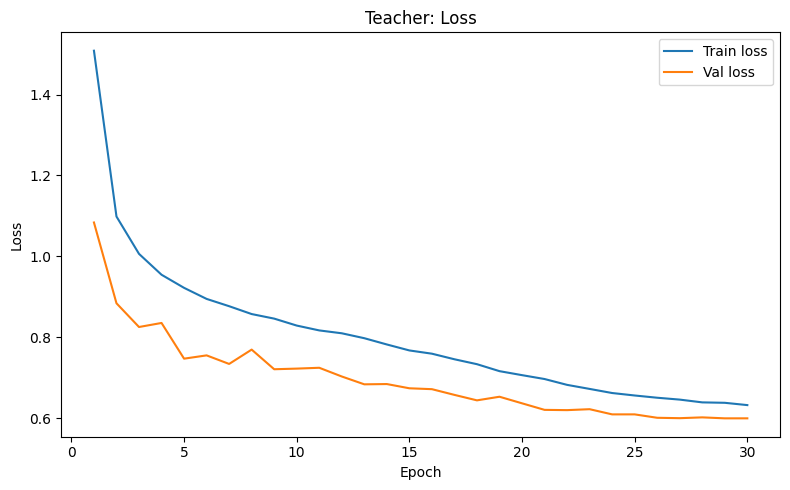

Saved results/plots/teacher_curves_acc.png


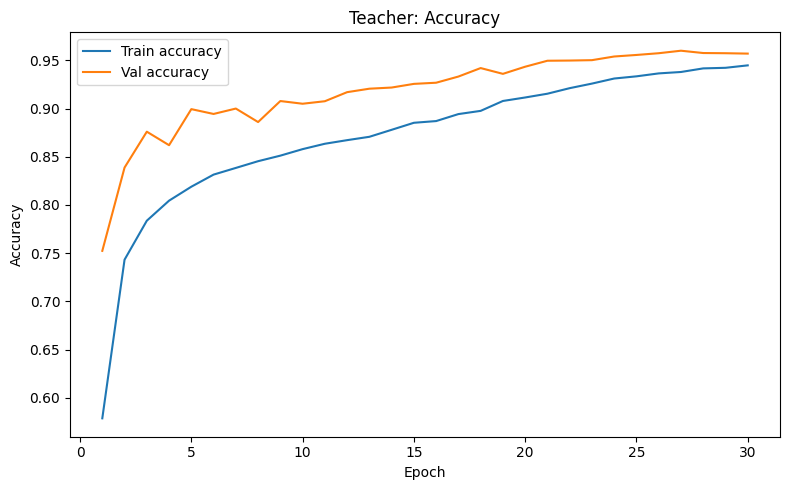

Saved results/plots/baseline_curves.png


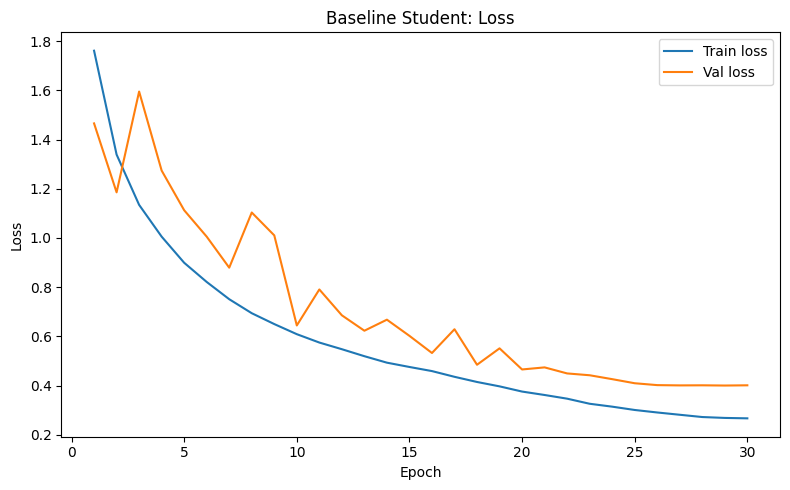

Saved results/plots/baseline_curves_acc.png


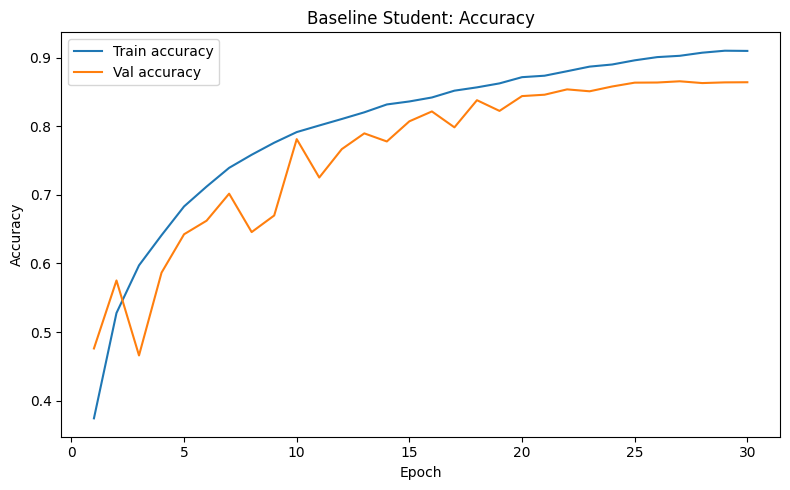

Saved results/plots/distilled_curves.png


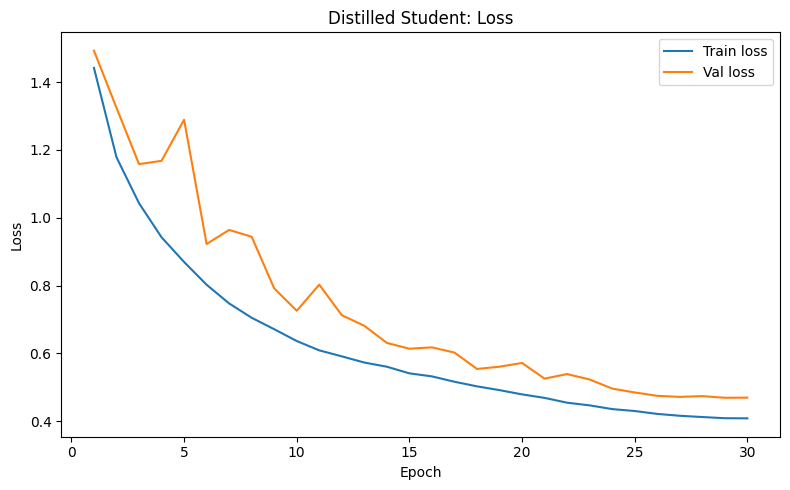

Saved results/plots/distilled_curves_acc.png


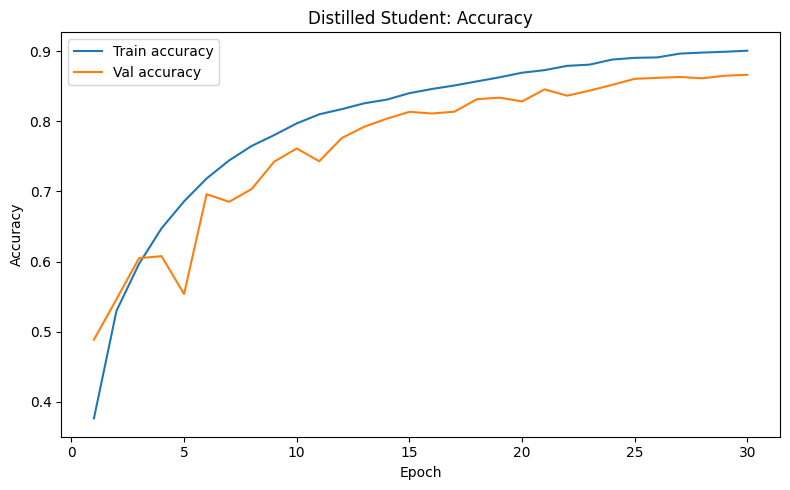

In [16]:
# Plot training curves

def plot_history(history, title_prefix, save_name=None):
    if history is None:
        print(f'No history available for {title_prefix}.')
        return

    epochs = range(1, len(history['train_loss']) + 1)

    plt.figure()
    plt.plot(epochs, history['train_loss'], label='Train loss')
    plt.plot(epochs, history['val_loss'], label='Val loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'{title_prefix}: Loss')
    plt.legend()
    plt.tight_layout()
    if save_name:
        path = PLOTS_DIR / save_name
        plt.savefig(path)
        print('Saved', path)
    plt.show()

    plt.figure()
    plt.plot(epochs, history['train_acc'], label='Train accuracy')
    plt.plot(epochs, history['val_acc'], label='Val accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title(f'{title_prefix}: Accuracy')
    plt.legend()
    plt.tight_layout()
    if save_name:
        path = PLOTS_DIR / save_name.replace('.png', '_acc.png')
        plt.savefig(path)
        print('Saved', path)
    plt.show()

plot_history(teacher_history, 'Teacher', 'teacher_curves.png')
plot_history(baseline_history, 'Baseline Student', 'baseline_curves.png')
plot_history(distill_history, 'Distilled Student', 'distilled_curves.png')


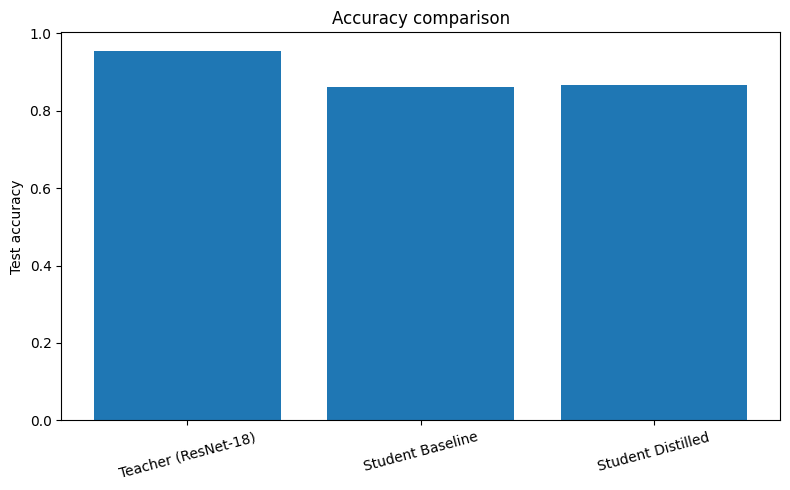

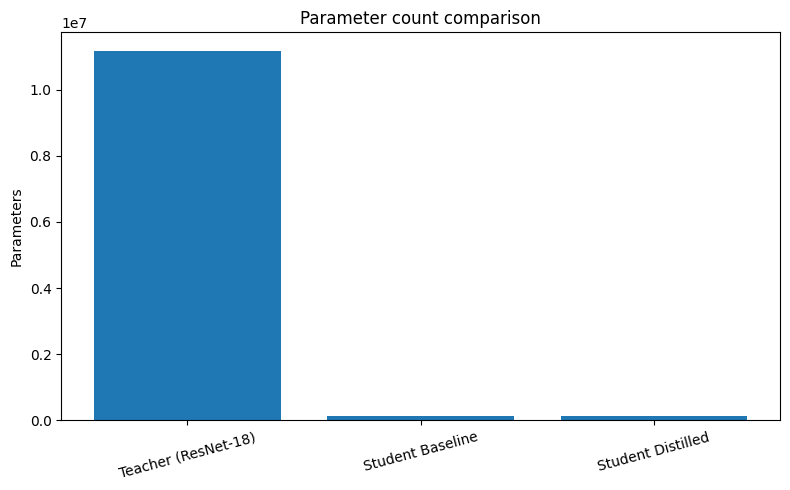

In [17]:
# Bar charts for final comparison
if len(metrics_df) > 0:
    plt.figure()
    plt.bar(metrics_df['model'], metrics_df['test_accuracy'])
    plt.ylabel('Test accuracy')
    plt.title('Accuracy comparison')
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / 'accuracy_comparison.png', dpi=200)
    plt.show()

    plt.figure()
    plt.bar(metrics_df['model'], metrics_df['parameters'])
    plt.ylabel('Parameters')
    plt.title('Parameter count comparison')
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / 'parameter_comparison.png', dpi=200)
    plt.show()


## Hyperparameter Sweep

This section runs a small experiment over **temperature** and **alpha** values. You can reduce the number of settings if training time is limited.


In [18]:
# Hyperparameter sweep
# This is resumable: completed settings in results/experiment_results.csv are skipped.
sweep_results = []

if RUN_SWEEP:
    temperature_values = [2.0, 4.0, 6.0, 8.0]
    alpha_values = [0.3, 0.5, 0.7, 0.9]

    if EXPERIMENTS_PATH.exists():
        existing_df = pd.read_csv(EXPERIMENTS_PATH)
        sweep_results = existing_df.to_dict('records')
        completed = set(zip(existing_df['temperature'].astype(float), existing_df['alpha'].astype(float)))
    else:
        completed = set()

    for temp in temperature_values:
        for alpha_value in alpha_values:
            key = (float(temp), float(alpha_value))
            if key in completed:
                print(f'Skipping completed setting: temperature={temp}, alpha={alpha_value}')
                continue

            print(f'Running sweep: temperature={temp}, alpha={alpha_value}')
            set_seed(SEED)
            student = get_student_model(base_channels=32)
            student.load_state_dict(initial_student_state)

            student, hist, best_val = fit_distillation_student(
                student,
                teacher,
                student_train_loader,
                val_loader,
                epochs=SWEEP_EPOCHS,
                temperature=temp,
                alpha=alpha_value,
                lr=STUDENT_LR,
                weight_decay=STUDENT_WEIGHT_DECAY,
            )
            test_loss, test_acc = evaluate_model(student, test_loader, nn.CrossEntropyLoss(), DEVICE)

            sweep_results.append({
                'temperature': temp,
                'alpha': alpha_value,
                'best_val_acc': best_val,
                'test_acc': test_acc,
            })

            # Save after each setting so progress is not lost if the session ends.
            sweep_df = pd.DataFrame(sweep_results).sort_values(['temperature', 'alpha']).reset_index(drop=True)
            sweep_df.to_csv(EXPERIMENTS_PATH, index=False)
            print(f'Saved partial sweep results to {EXPERIMENTS_PATH}')

    sweep_df = pd.DataFrame(sweep_results).sort_values(['temperature', 'alpha']).reset_index(drop=True)
    sweep_df.to_csv(EXPERIMENTS_PATH, index=False)
    print(f'Saved sweep results to {EXPERIMENTS_PATH}')
    display(sweep_df)
else:
    if EXPERIMENTS_PATH.exists():
        sweep_df = pd.read_csv(EXPERIMENTS_PATH)
        display(sweep_df)
    else:
        sweep_df = pd.DataFrame()
        print('No sweep results found.')


,temperature,alpha,best_val_acc,test_acc
0,2.0,0.3,0.7738,0.7793
1,2.0,0.5,0.7692,0.7750
2,2.0,0.7,0.7742,0.7800
3,2.0,0.9,0.7758,0.7793
4,4.0,0.3,0.7760,0.7833
5,4.0,0.5,0.7730,0.7732
6,4.0,0.7,0.7772,0.7794
7,4.0,0.9,0.7798,0.7825
8,6.0,0.3,0.7790,0.7869
9,6.0,0.5,0.7692,0.7807


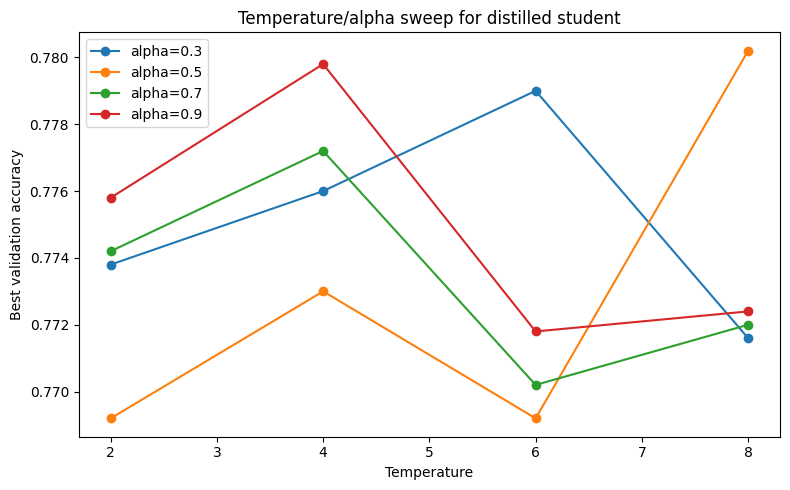

In [19]:
# Sweep plot
# Use validation accuracy for hyperparameter selection to avoid tuning directly on the test set.
if 'sweep_df' in globals() and len(sweep_df) > 0:
    for alpha_value in sorted(sweep_df['alpha'].unique()):
        subset = sweep_df[sweep_df['alpha'] == alpha_value].sort_values('temperature')
        plt.plot(subset['temperature'], subset['best_val_acc'], marker='o', label=f'alpha={alpha_value}')

    plt.xlabel('Temperature')
    plt.ylabel('Best validation accuracy')
    plt.title('Temperature/alpha sweep for distilled student')
    plt.legend()
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / 'temperature_sweep.png', dpi=200)
    plt.show()


## Demo: Sample Predictions

This section shows predictions from the teacher, baseline student, and distilled student on a few test images.


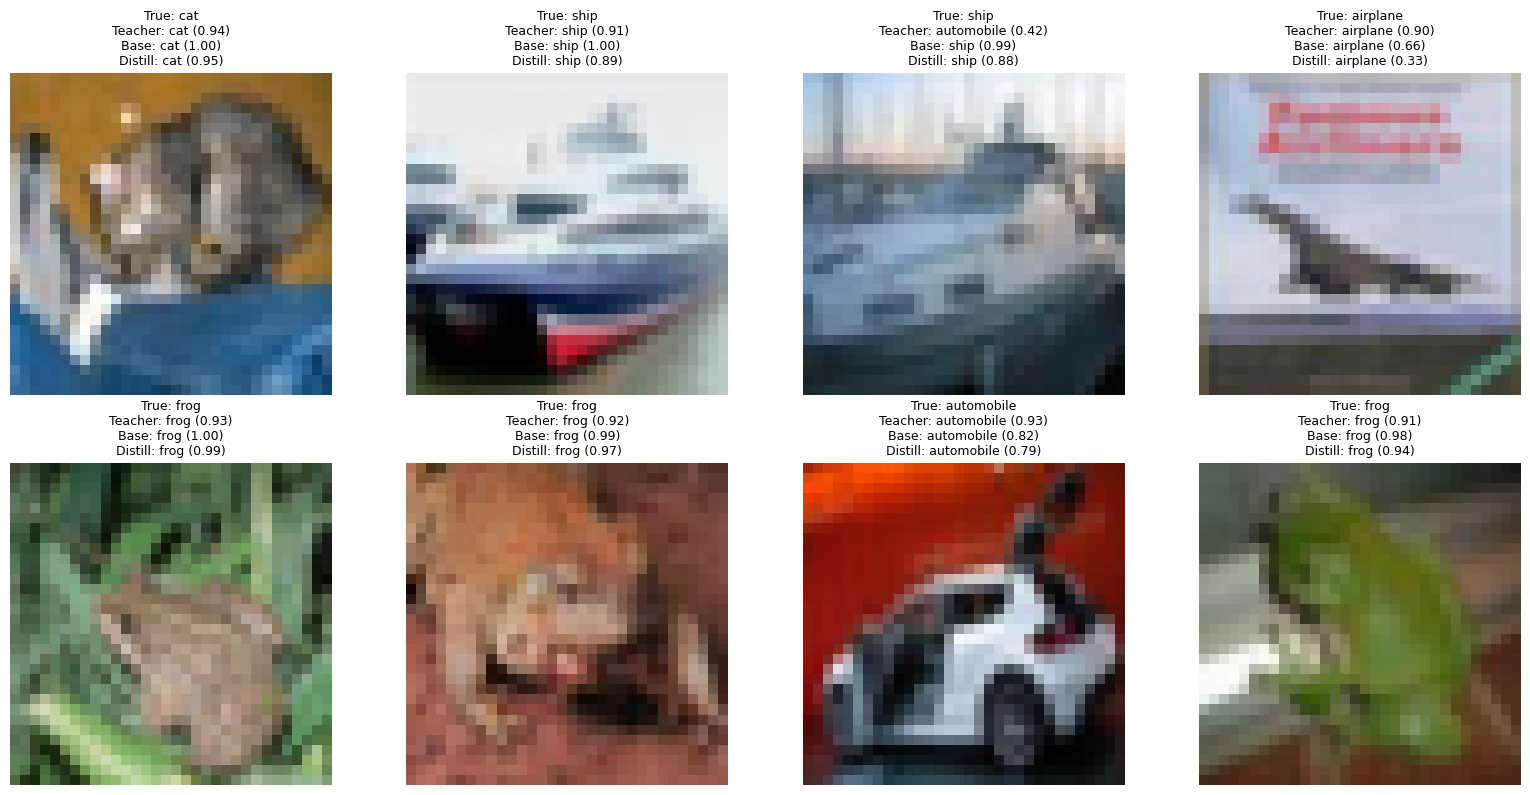

In [20]:
# Demo predictions
@torch.no_grad()
def get_predictions(model, images, device=DEVICE):
    model.eval()
    logits = model(images.to(device, non_blocking=PIN_MEMORY))
    probs = F.softmax(logits, dim=1)
    confs, preds = probs.max(dim=1)
    return preds.cpu(), confs.cpu(), probs.cpu()


images, labels = next(iter(test_loader))
images_small = images[:8]
labels_small = labels[:8]

teacher_preds, teacher_confs, _ = get_predictions(teacher, images_small)
baseline_preds, baseline_confs, _ = get_predictions(baseline_student, images_small)
distilled_preds, distilled_confs, _ = get_predictions(distilled_student, images_small)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, ax in enumerate(axes.flat):
    img = denormalize(images_small[i]).clamp(0, 1)
    ax.imshow(img.permute(1, 2, 0).numpy())

    true_label = classes[int(labels_small[i])]
    teacher_label = classes[int(teacher_preds[i])]
    baseline_label = classes[int(baseline_preds[i])]
    distilled_label = classes[int(distilled_preds[i])]

    ax.set_title(
        f'True: {true_label}\n'
        f'Teacher: {teacher_label} ({teacher_confs[i]:.2f})\n'
        f'Base: {baseline_label} ({baseline_confs[i]:.2f})\n'
        f'Distill: {distilled_label} ({distilled_confs[i]:.2f})',
        fontsize=9
    )
    ax.axis('off')

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'demo_predictions.png', dpi=200)
plt.show()
